In [23]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from aeon.transformations.collection.convolution_based import Rocket
from sklearn.linear_model import RidgeClassifierCV
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

from scripts.covfee_baseline_utils import (
    BACKGROUND_LABEL,
    CANONICAL_LABEL_ORDER,
    CHANNEL_COLUMNS,
    SPLIT_CONFIGS,
    TARGET_COLUMN,
    build_annotation_splits,
    build_grouped_windows,
    evaluate_split,
    evaluate_timeline_diagnostics,
    filter_windows,
    label_order_from_values,
    load_covfee_manual_data,
    summarize_splits,
)


In [24]:
COVFEE_OUTPUT_DIR = Path("outputs") / "covfee"
WINDOW_SECONDS = 1.0
STRIDE_SECONDS = 1.0
TARGET_FS = None
MIN_LABEL_PURITY = 0.0
DROP_STILL_WINDOWS = False

NUM_KERNELS = 10000
RANDOM_SEED = 42

SPLIT_CONFIGS


{'split_A_eval_01_v1': {'eval_annotations': ['01_v1', '20_v2', '27_v2']},
 'split_B_eval_24_v1': {'eval_annotations': ['24_v1', '18_v2', '27_v2']}}

In [25]:
df, preprocessing_summary, DATA_PATH = load_covfee_manual_data(Path.cwd(), COVFEE_OUTPUT_DIR)

print(f"Rows: {len(df):,}")
print(f"Annotations: {df['annotation_id'].nunique()}")
display(preprocessing_summary[["annotation_id", "status", "video_start", "video_end", "rows", "windows"]])
display(df.head())
display(df[TARGET_COLUMN].value_counts().rename("sample_count").to_frame())
DATA_PATH


Rows: 150,000
Annotations: 10


,annotation_id,status,video_start,video_end,rows,windows
0,01_v1,ok,2025-07-17 14:02:30.166833333,2025-07-17 14:07:30.166833333,15000,150
1,03_v1,ok,2025-07-17 14:02:30.166833333,2025-07-17 14:07:30.166833333,15000,150
2,03_v2,ok,2025-07-17 15:20:32.116783333,2025-07-17 15:25:32.116783333,15000,150
3,16_v1,ok,2025-07-17 14:02:30.166833333,2025-07-17 14:07:30.166833333,15000,150
4,16_v2,ok,2025-07-17 15:20:32.116783333,2025-07-17 15:25:32.116783333,15000,150
5,17_v1,ok,2025-07-17 14:02:30.166833333,2025-07-17 14:07:30.166833333,15000,150
6,18_v2,ok,2025-07-17 15:20:32.116783333,2025-07-17 15:25:32.116783333,15000,150
7,20_v2,ok,2025-07-17 15:20:32.116783333,2025-07-17 15:25:32.116783333,15000,150
8,24_v1,ok,2025-07-17 14:02:30.166833333,2025-07-17 14:07:30.166833333,15000,150
9,27_v2,ok,2025-07-17 15:20:32.116783333,2025-07-17 15:25:32.116783333,15000,150


,time,x,y,z,state,manual_label,video_name,participant_no,participant_id,annotation_id,alignment_mode,preprocessed_at
0,2025-07-17 14:02:30.180,-0.197876,-0.151733,-0.875854,0,Still,v1,1,81,01_v1,hardcoded_source_clip_offset,2026-05-05 11:58:47
1,2025-07-17 14:02:30.200,-0.194946,-0.140503,-0.872925,0,Still,v1,1,81,01_v1,hardcoded_source_clip_offset,2026-05-05 11:58:47
2,2025-07-17 14:02:30.220,-0.158813,-0.128296,-0.875366,0,Still,v1,1,81,01_v1,hardcoded_source_clip_offset,2026-05-05 11:58:47
3,2025-07-17 14:02:30.240,-0.170044,-0.129272,-0.915894,0,Still,v1,1,81,01_v1,hardcoded_source_clip_offset,2026-05-05 11:58:47
4,2025-07-17 14:02:30.260,-0.178345,-0.126831,-0.951050,0,Still,v1,1,81,01_v1,hardcoded_source_clip_offset,2026-05-05 11:58:47


,sample_count
manual_label,
Still,110061
Gesture,26953
Nodding,11833
Drinking,987
Toasting,166


WindowsPath('outputs/covfee/covfee_manual_labels_combined.csv')

In [26]:
X_all, y_all, meta_all, sampling_summary, window_size, stride_size = build_grouped_windows(
    df,
    channel_columns=CHANNEL_COLUMNS,
    target_column=TARGET_COLUMN,
    target_fs=TARGET_FS,
    window_seconds=WINDOW_SECONDS,
    stride_seconds=STRIDE_SECONDS,
)

X, y, meta, filter_diagnostics = filter_windows(
    X_all,
    y_all,
    meta_all,
    min_label_purity=MIN_LABEL_PURITY,
    background_label=BACKGROUND_LABEL,
    drop_still_windows=DROP_STILL_WINDOWS,
)
label_order = label_order_from_values(y)

print(f"Median effective sampling rate: {sampling_summary['estimated_fs'].median():.2f} Hz")
print(f"Window size: {window_size} samples")
print(f"Stride size: {stride_size} samples")
print(f"Window tensor shape: {X.shape}  # (n_windows, n_channels, window_length)")
print(f"Drop Still/background windows: {DROP_STILL_WINDOWS}")
print(f"Removed by purity filter: {filter_diagnostics['n_removed_by_purity']:,}")
print(f"Removed Still/background windows: {filter_diagnostics['n_removed_background']:,}")
display(sampling_summary)
display(meta.head())
display(pd.Series(y).value_counts().reindex(label_order, fill_value=0).rename("window_count").to_frame())


Median effective sampling rate: 50.00 Hz
Window size: 50 samples
Stride size: 50 samples
Window tensor shape: (3000, 3, 50)  # (n_windows, n_channels, window_length)
Drop Still/background windows: False
Removed by purity filter: 0
Removed Still/background windows: 0


,annotation_id,estimated_fs,rows
0,01_v1,50.0,15000
1,03_v1,50.0,15000
2,03_v2,50.0,15000
3,16_v1,50.0,15000
4,16_v2,50.0,15000
5,17_v1,50.0,15000
6,18_v2,50.0,15000
7,20_v2,50.0,15000
8,24_v1,50.0,15000
9,27_v2,50.0,15000


,start_idx,end_idx,start_time,end_time,label,purity,n_unique_labels,annotation_id,participant_no,participant_id,video_name,alignment_mode,estimated_fs
0,0,50,2025-07-17 14:02:30.180,2025-07-17 14:02:31.160,Gesture,0.7,2,01_v1,1,81,v1,hardcoded_source_clip_offset,50.0
1,50,100,2025-07-17 14:02:31.180,2025-07-17 14:02:32.160,Gesture,1.0,1,01_v1,1,81,v1,hardcoded_source_clip_offset,50.0
2,100,150,2025-07-17 14:02:32.180,2025-07-17 14:02:33.160,Gesture,1.0,1,01_v1,1,81,v1,hardcoded_source_clip_offset,50.0
3,150,200,2025-07-17 14:02:33.180,2025-07-17 14:02:34.160,Gesture,1.0,1,01_v1,1,81,v1,hardcoded_source_clip_offset,50.0
4,200,250,2025-07-17 14:02:34.180,2025-07-17 14:02:35.160,Gesture,1.0,1,01_v1,1,81,v1,hardcoded_source_clip_offset,50.0


,window_count
Still,2204
Gesture,544
Nodding,228
Drinking,20
Toasting,4


In [27]:
purity_summary = pd.DataFrame(
    {
        "metric": [
            "n_windows",
            "mean_purity",
            "median_purity",
            "pure_windows_ratio",
            "mixed_windows_ratio",
            "purity_ge_0.9_ratio",
            "purity_ge_0.8_ratio",
        ],
        "value": [
            len(meta),
            meta["purity"].mean(),
            meta["purity"].median(),
            (meta["purity"] == 1.0).mean(),
            (meta["purity"] < 1.0).mean(),
            (meta["purity"] >= 0.9).mean(),
            (meta["purity"] >= 0.8).mean(),
        ],
    }
)
display(purity_summary)
display(meta[["purity", "n_unique_labels"]].describe())


,metric,value
0,n_windows,3000.000000
1,mean_purity,0.932167
2,median_purity,1.000000
3,pure_windows_ratio,0.756333
4,mixed_windows_ratio,0.243667
5,purity_ge_0.9_ratio,0.791667
6,purity_ge_0.8_ratio,0.841000


,purity,n_unique_labels
count,3000.000000,3000.00000
mean,0.932167,1.24900
std,0.137840,0.44467
min,0.360000,1.00000
25%,1.000000,1.00000
50%,1.000000,1.00000
75%,1.000000,1.00000
max,1.000000,3.00000


In [28]:
splits = build_annotation_splits(X, y, meta, SPLIT_CONFIGS)
split_summary, label_counts_df, annotation_split_df = summarize_splits(splits, label_order)

display(split_summary)
display(label_counts_df)
display(annotation_split_df)


,split_config,subset,n_windows,annotations,start,end
0,split_A_eval_01_v1,train,2100,7,2025-07-17 14:02:30.180,2025-07-17 15:25:32.100
1,split_A_eval_01_v1,eval,900,3,2025-07-17 14:02:30.180,2025-07-17 15:25:32.100
2,split_B_eval_24_v1,train,2100,7,2025-07-17 14:02:30.180,2025-07-17 15:25:32.100
3,split_B_eval_24_v1,eval,900,3,2025-07-17 14:02:30.180,2025-07-17 15:25:32.100


subset                       eval  train
split_config       label                
split_A_eval_01_v1 Drinking     5     15
                   Gesture    163    381
                   Nodding     96    132
                   Still      634   1570
                   Toasting     2      2
split_B_eval_24_v1 Drinking     4     16
                   Gesture    194    350
                   Nodding     93    135
                   Still      607   1597
                   Toasting     2      2

subset                            eval  train
split_config       annotation_id             
split_A_eval_01_v1 01_v1           300      0
                   03_v1             0    300
                   03_v2             0    300
                   16_v1             0    300
                   16_v2             0    300
                   17_v1             0    300
                   18_v2             0    300
                   20_v2           300      0
                   24_v1             0    300
                   27_v2           300      0
split_B_eval_24_v1 01_v1             0    300
                   03_v1             0    300
                   03_v2             0    300
                   16_v1             0    300
                   16_v2             0    300
                   17_v1             0    300
                   18_v2           300      0
                   20_v2             0    300
                   24_v1           300      0
                   27_v2           300      0

In [29]:
rockets = {}
classifiers = {}
predictions = {}
eval_prediction_tables = {}
reports = {}
train_results = []
eval_split_results = []
eval_annotation_results = []
timeline_diagnostics = []
eval_split_timeline_diagnostics = []

for split_name, split_data in splits.items():
    print(f"Fitting multivariate ROCKET for {split_name}...")
    rocket = Rocket(n_kernels=NUM_KERNELS, random_state=RANDOM_SEED, n_jobs=-1)
    rocket.fit(split_data["x_train"])
    X_train_transform = rocket.transform(split_data["x_train"])
    X_eval_transform = rocket.transform(split_data["x_eval"])

    classifier = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
    classifier.fit(X_train_transform, split_data["y_train"])

    split_predictions = {
        "train": classifier.predict(X_train_transform),
        "eval": classifier.predict(X_eval_transform),
    }
    rockets[split_name] = rocket
    classifiers[split_name] = classifier
    predictions[split_name] = split_predictions
    eval_prediction_tables[split_name] = split_data["eval_meta"][["annotation_id", "start_time", "end_time", "purity"]].assign(
        y_true=split_data["y_eval"],
        y_pred=split_predictions["eval"],
    )

    reports[split_name] = {"eval_split": classification_report(split_data["y_eval"], split_predictions["eval"], labels=label_order, zero_division=0), "eval_annotations": {}}
    train_results.append({"split_config": split_name, "annotation_id": "ALL_TRAIN", "model": "rocket_multi", **evaluate_split("train", split_data["y_train"], split_predictions["train"])})
    eval_split_results.append({"split_config": split_name, "annotation_id": "ALL_EVAL", "model": "rocket_multi", **evaluate_split("eval_split", split_data["y_eval"], split_predictions["eval"])})
    timeline_diagnostics.append({"split_config": split_name, "annotation_id": "ALL_TRAIN", "model": "rocket_multi", **evaluate_timeline_diagnostics("train", split_data["y_train"], split_predictions["train"])})
    eval_split_timeline_diagnostics.append({"split_config": split_name, "annotation_id": "ALL_EVAL", "model": "rocket_multi", **evaluate_timeline_diagnostics("eval_split", split_data["y_eval"], split_predictions["eval"])})

    for annotation_id in split_data["eval_meta"]["annotation_id"].drop_duplicates():
        annotation_mask = split_data["eval_meta"]["annotation_id"].eq(annotation_id).to_numpy()
        y_eval_annotation = split_data["y_eval"][annotation_mask]
        eval_pred_annotation = split_predictions["eval"][annotation_mask]
        reports[split_name]["eval_annotations"][annotation_id] = classification_report(
            y_eval_annotation,
            eval_pred_annotation,
            labels=label_order,
            zero_division=0,
        )
        eval_annotation_results.append({"split_config": split_name, "annotation_id": annotation_id, "model": "rocket_multi", **evaluate_split("eval_annotation", y_eval_annotation, eval_pred_annotation)})
        timeline_diagnostics.append({"split_config": split_name, "annotation_id": annotation_id, "model": "rocket_multi", **evaluate_timeline_diagnostics("eval_annotation", y_eval_annotation, eval_pred_annotation)})

results_df = pd.DataFrame(train_results + eval_annotation_results)
eval_split_summary_df = pd.DataFrame(eval_split_results)
timeline_diagnostics_df = pd.DataFrame(timeline_diagnostics)
eval_split_timeline_diagnostics_df = pd.DataFrame(eval_split_timeline_diagnostics)

display(results_df)
display(eval_split_summary_df)
display(timeline_diagnostics_df)
display(eval_split_timeline_diagnostics_df)


Fitting multivariate ROCKET for split_A_eval_01_v1...
Fitting multivariate ROCKET for split_B_eval_24_v1...


,split_config,annotation_id,model,split,accuracy,macro_precision,macro_recall,macro_f1,active_accuracy,active_macro_precision_no_still,active_macro_recall_no_still,active_macro_f1_no_still,n_samples,active_n_samples
0,split_A_eval_01_v1,ALL_TRAIN,rocket_multi,train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2100,530
1,split_B_eval_24_v1,ALL_TRAIN,rocket_multi,train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2100,503
2,split_A_eval_01_v1,01_v1,rocket_multi,eval_annotation,0.560000,0.388816,0.265130,0.253121,0.128205,0.574074,0.074819,0.125211,300,117
3,split_A_eval_01_v1,20_v2,rocket_multi,eval_annotation,0.686667,0.223100,0.229439,0.224363,0.063830,0.200000,0.038462,0.064516,300,47
4,split_A_eval_01_v1,27_v2,rocket_multi,eval_annotation,0.576667,0.349482,0.355829,0.345759,0.166667,0.630952,0.139805,0.214866,300,102
5,split_B_eval_24_v1,18_v2,rocket_multi,eval_annotation,0.680000,0.290210,0.297778,0.293806,0.346667,0.309524,0.133333,0.186380,300,75
6,split_B_eval_24_v1,24_v1,rocket_multi,eval_annotation,0.566667,0.211500,0.219234,0.206785,0.146552,0.273148,0.066162,0.096660,300,116
7,split_B_eval_24_v1,27_v2,rocket_multi,eval_annotation,0.600000,0.410078,0.370518,0.367432,0.156863,0.825000,0.141636,0.228055,300,102


,split_config,annotation_id,model,split,accuracy,macro_precision,macro_recall,macro_f1,active_accuracy,active_macro_precision_no_still,active_macro_recall_no_still,active_macro_f1_no_still,n_samples,active_n_samples
0,split_A_eval_01_v1,ALL_EVAL,rocket_multi,eval_split,0.607778,0.209110,0.207028,0.201571,0.131579,0.369318,0.056892,0.092295,900,266
1,split_B_eval_24_v1,ALL_EVAL,rocket_multi,eval_split,0.615556,0.237897,0.228400,0.225186,0.201365,0.350000,0.081629,0.122433,900,293


,split_config,annotation_id,model,split,background_windows,active_windows,background_recall,false_activity_rate_on_background,active_accuracy_on_active_windows,active_macro_f1_no_still_on_active_windows
0,split_A_eval_01_v1,ALL_TRAIN,rocket_multi,train,1570,530,1.000000,0.000000,1.000000,1.000000
1,split_A_eval_01_v1,01_v1,rocket_multi,eval_annotation,183,117,0.836066,0.163934,0.128205,0.125211
2,split_A_eval_01_v1,20_v2,rocket_multi,eval_annotation,253,47,0.802372,0.197628,0.063830,0.064516
3,split_A_eval_01_v1,27_v2,rocket_multi,eval_annotation,198,102,0.787879,0.212121,0.166667,0.214866
4,split_B_eval_24_v1,ALL_TRAIN,rocket_multi,train,1597,503,1.000000,0.000000,1.000000,1.000000
5,split_B_eval_24_v1,18_v2,rocket_multi,eval_annotation,225,75,0.791111,0.208889,0.346667,0.186380
6,split_B_eval_24_v1,24_v1,rocket_multi,eval_annotation,184,116,0.831522,0.168478,0.146552,0.096660
7,split_B_eval_24_v1,27_v2,rocket_multi,eval_annotation,198,102,0.828283,0.171717,0.156863,0.228055


,split_config,annotation_id,model,split,background_windows,active_windows,background_recall,false_activity_rate_on_background,active_accuracy_on_active_windows,active_macro_f1_no_still_on_active_windows
0,split_A_eval_01_v1,ALL_EVAL,rocket_multi,eval_split,634,266,0.807571,0.192429,0.131579,0.092295
1,split_B_eval_24_v1,ALL_EVAL,rocket_multi,eval_split,607,293,0.815486,0.184514,0.201365,0.122433


In [30]:
for split_name, split_reports in reports.items():
    for annotation_id, report_text in split_reports["eval_annotations"].items():
        print(f"=== {split_name} / {annotation_id} / rocket_multi / eval_annotation ===")
        print(report_text)

display(eval_prediction_tables["split_A_eval_01_v1"].head(20))


=== split_A_eval_01_v1 / 01_v1 / rocket_multi / eval_annotation ===
              precision    recall  f1-score   support

       Still       0.61      0.84      0.71       183
     Gesture       0.28      0.18      0.21        74
     Nodding       0.67      0.05      0.09        41
    Drinking       0.00      0.00      0.00         0
    Toasting       0.00      0.00      0.00         2

    accuracy                           0.56       300
   macro avg       0.31      0.21      0.20       300
weighted avg       0.53      0.56      0.50       300

=== split_A_eval_01_v1 / 20_v2 / rocket_multi / eval_annotation ===
              precision    recall  f1-score   support

       Still       0.83      0.80      0.82       253
     Gesture       0.06      0.12      0.08        26
     Nodding       0.00      0.00      0.00        16
    Drinking       0.00      0.00      0.00         5
    Toasting       0.00      0.00      0.00         0

    accuracy                           0.69      

,annotation_id,start_time,end_time,purity,y_true,y_pred
0,01_v1,2025-07-17 14:02:30.180,2025-07-17 14:02:31.160,0.70,Gesture,Still
1,01_v1,2025-07-17 14:02:31.180,2025-07-17 14:02:32.160,1.00,Gesture,Gesture
2,01_v1,2025-07-17 14:02:32.180,2025-07-17 14:02:33.160,1.00,Gesture,Gesture
3,01_v1,2025-07-17 14:02:33.180,2025-07-17 14:02:34.160,1.00,Gesture,Gesture
4,01_v1,2025-07-17 14:02:34.180,2025-07-17 14:02:35.160,1.00,Gesture,Still
5,01_v1,2025-07-17 14:02:35.180,2025-07-17 14:02:36.160,1.00,Gesture,Still
6,01_v1,2025-07-17 14:02:36.180,2025-07-17 14:02:37.160,1.00,Gesture,Still
7,01_v1,2025-07-17 14:02:37.180,2025-07-17 14:02:38.160,0.68,Still,Still
8,01_v1,2025-07-17 14:02:38.180,2025-07-17 14:02:39.160,1.00,Still,Still
9,01_v1,2025-07-17 14:02:39.180,2025-07-17 14:02:40.160,0.92,Gesture,Still


In [31]:
LABEL_COLORS = {
    "Still": "#d9d9d9",
    "Gesture": "#f4a261",
    "Drinking": "#2a9d8f",
    "Toasting": "#577590",
    "Nodding": "#b56576",
}


def build_sample_runs(frame: pd.DataFrame, time_col: str, label_col: str, origin: pd.Timestamp):
    frame = frame[[time_col, label_col]].sort_values(time_col).reset_index(drop=True)
    runs = []
    if frame.empty:
        return runs
    start_idx = 0
    for i in range(1, len(frame) + 1):
        if i == len(frame) or frame.loc[i, label_col] != frame.loc[i - 1, label_col]:
            runs.append(
                (
                    (frame.loc[start_idx, time_col] - origin).total_seconds(),
                    (frame.loc[i - 1, time_col] - origin).total_seconds(),
                    frame.loc[i - 1, label_col],
                )
            )
            start_idx = i
    return runs


def build_interval_runs(frame: pd.DataFrame, start_col: str, end_col: str, label_col: str, origin: pd.Timestamp):
    frame = frame[[start_col, end_col, label_col]].sort_values(start_col).reset_index(drop=True)
    runs = []
    if frame.empty:
        return runs

    gap_tolerance = pd.Timedelta(milliseconds=25)
    current_start = frame.loc[0, start_col]
    current_end = frame.loc[0, end_col]
    current_label = frame.loc[0, label_col]

    for i in range(1, len(frame)):
        row = frame.loc[i]
        if row[label_col] == current_label and row[start_col] <= current_end + gap_tolerance:
            current_end = max(current_end, row[end_col])
        else:
            runs.append(((current_start - origin).total_seconds(), (current_end - origin).total_seconds(), current_label))
            current_start = row[start_col]
            current_end = row[end_col]
            current_label = row[label_col]

    runs.append(((current_start - origin).total_seconds(), (current_end - origin).total_seconds(), current_label))
    return runs


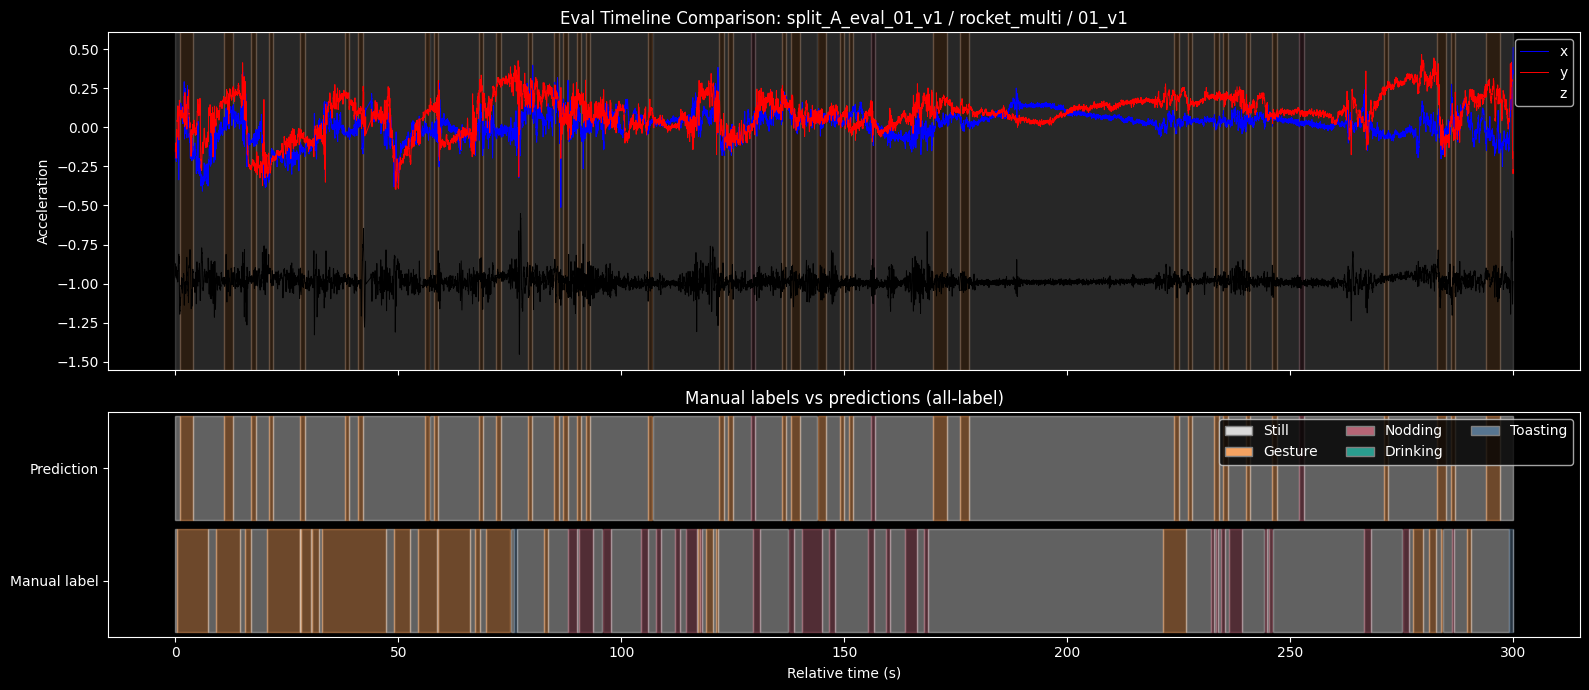

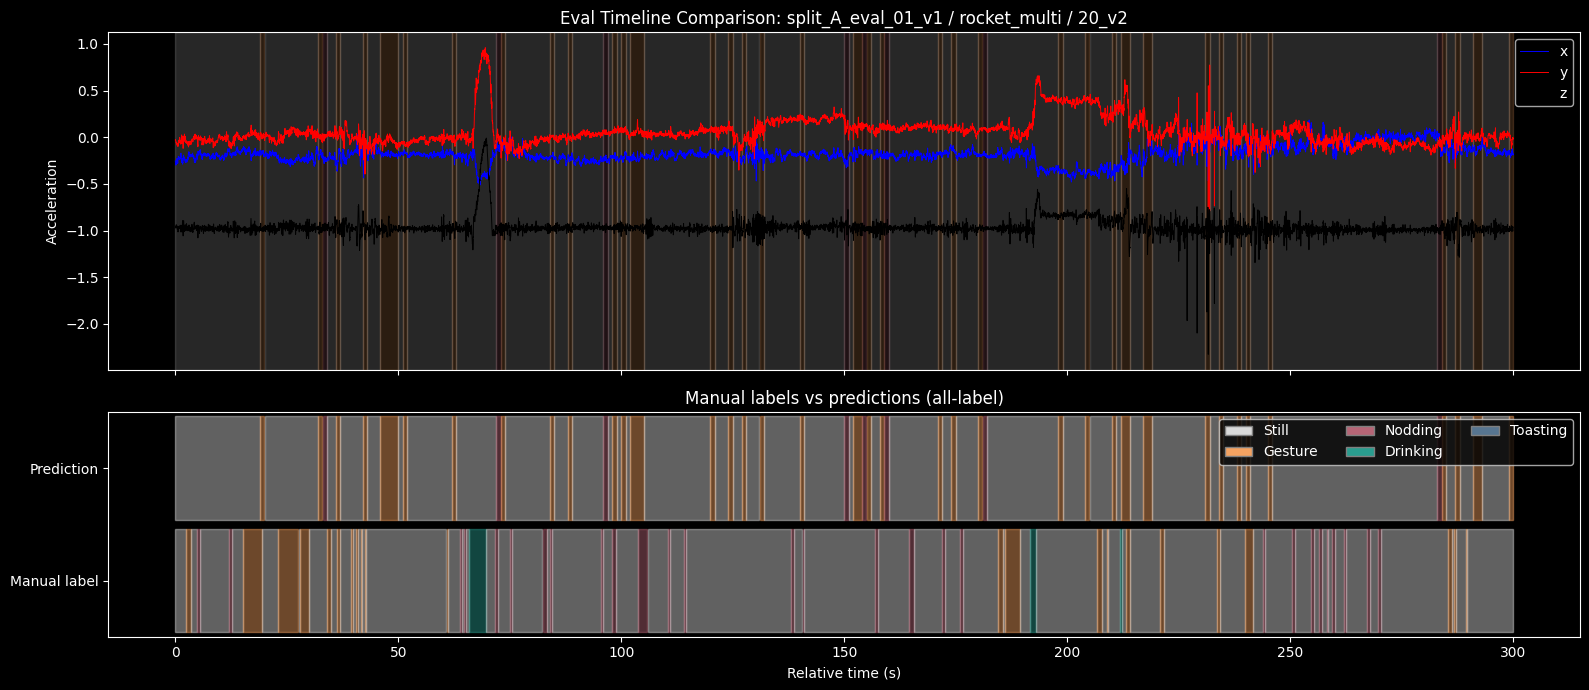

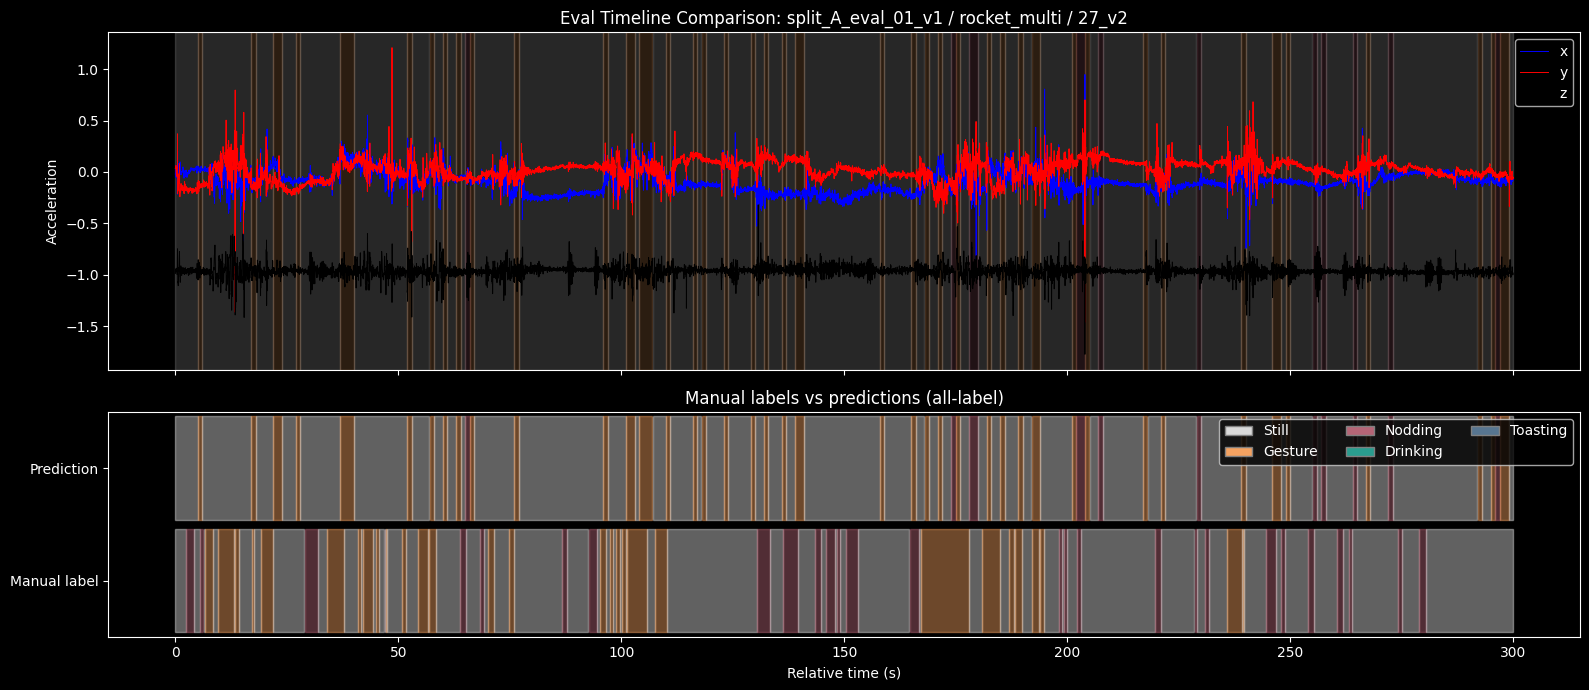

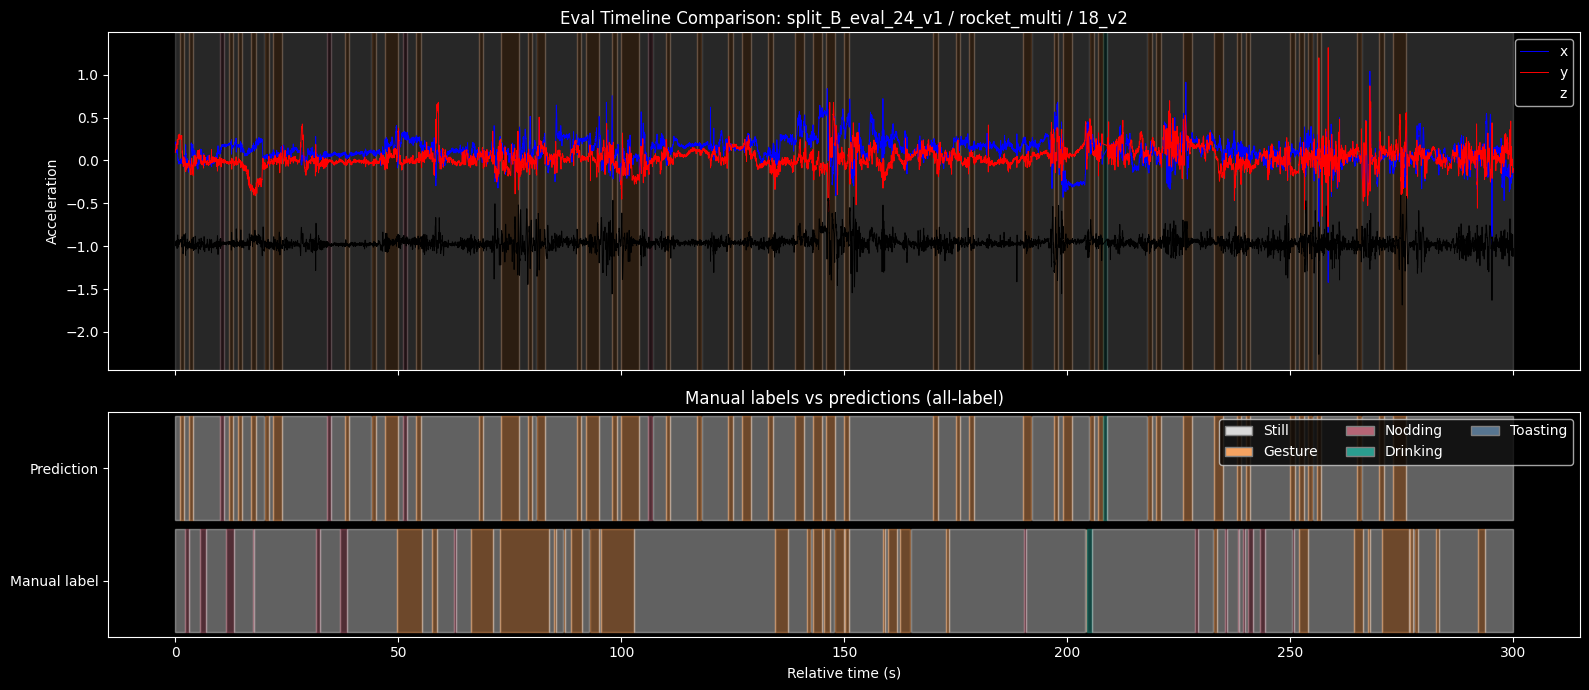

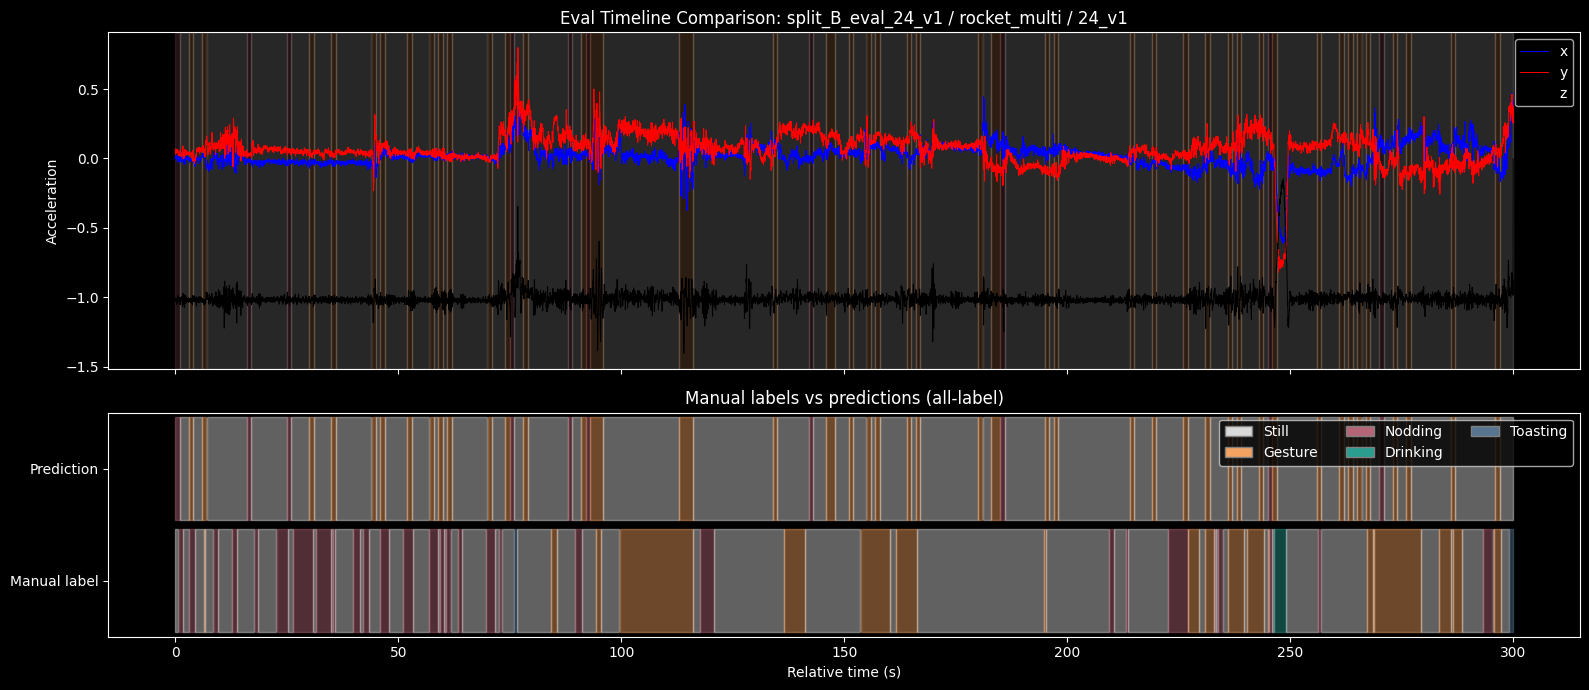

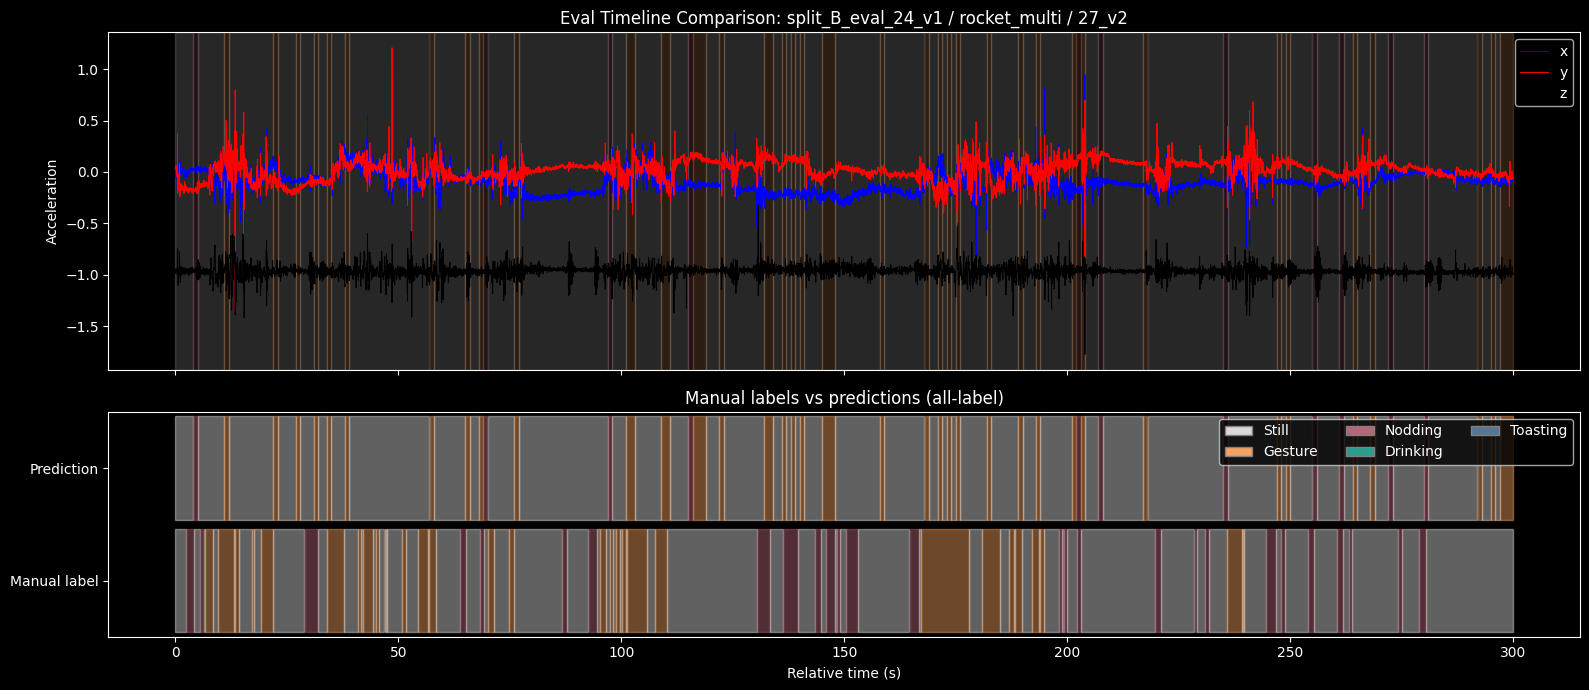

In [32]:
plot_task_name = "active-only" if DROP_STILL_WINDOWS else "all-label"
for split_name, split_data in splits.items():
    eval_with_pred = eval_prediction_tables[split_name]
    for plot_annotation_id in eval_with_pred["annotation_id"].drop_duplicates():
        eval_plot_df = eval_with_pred[eval_with_pred["annotation_id"] == plot_annotation_id].reset_index(drop=True)

        plot_start = eval_plot_df["start_time"].iloc[0]
        plot_end = eval_plot_df["end_time"].iloc[-1]
        plot_origin = plot_start

        acc_plot = df[
            (df["annotation_id"] == plot_annotation_id)
            & (df["time"] >= plot_start)
            & (df["time"] <= plot_end)
        ].copy().reset_index(drop=True)
        acc_plot["time_rel_s"] = (acc_plot["time"] - plot_origin).dt.total_seconds()

        manual_runs = build_sample_runs(acc_plot, "time", TARGET_COLUMN, plot_origin)
        predicted_runs = build_interval_runs(eval_plot_df, "start_time", "end_time", "y_pred", plot_origin)

        fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True, gridspec_kw={"height_ratios": [3, 2]})
        ax0, ax1 = axes

        for start_time, end_time, predicted_label in predicted_runs:
            ax0.axvspan(start_time, end_time, color=LABEL_COLORS.get(str(predicted_label), "#cccccc"), alpha=0.18)

        ax0.plot(acc_plot["time_rel_s"], acc_plot["x"], label="x", color="blue", linewidth=0.7)
        ax0.plot(acc_plot["time_rel_s"], acc_plot["y"], label="y", color="red", linewidth=0.7)
        ax0.plot(acc_plot["time_rel_s"], acc_plot["z"], label="z", color="black", linewidth=0.7)
        ax0.set_title(f"Eval Timeline Comparison: {split_name} / rocket_multi / {plot_annotation_id}")
        ax0.set_ylabel("Acceleration")
        ax0.legend(loc="upper right")

        for start_time, end_time, predicted_label in predicted_runs:
            ax1.axvspan(start_time, end_time, ymin=0.52, ymax=0.98, color=LABEL_COLORS.get(str(predicted_label), "#cccccc"), alpha=0.45)
        for start_time, end_time, manual_label in manual_runs:
            ax1.axvspan(start_time, end_time, ymin=0.02, ymax=0.48, color=LABEL_COLORS.get(str(manual_label), "#cccccc"), alpha=0.45)

        ax1.set_ylim(0, 1)
        ax1.set_yticks([0.25, 0.75])
        ax1.set_yticklabels(["Manual label", "Prediction"])
        ax1.set_title(f"Manual labels vs predictions ({plot_task_name})")
        ax1.set_xlabel("Relative time (s)")

        legend_handles = [Patch(facecolor=LABEL_COLORS[label], edgecolor="gray", label=label) for label in label_order]
        ax1.legend(handles=legend_handles, loc="upper right", ncol=min(3, max(1, len(legend_handles))))

        fig.tight_layout()
        plt.show()


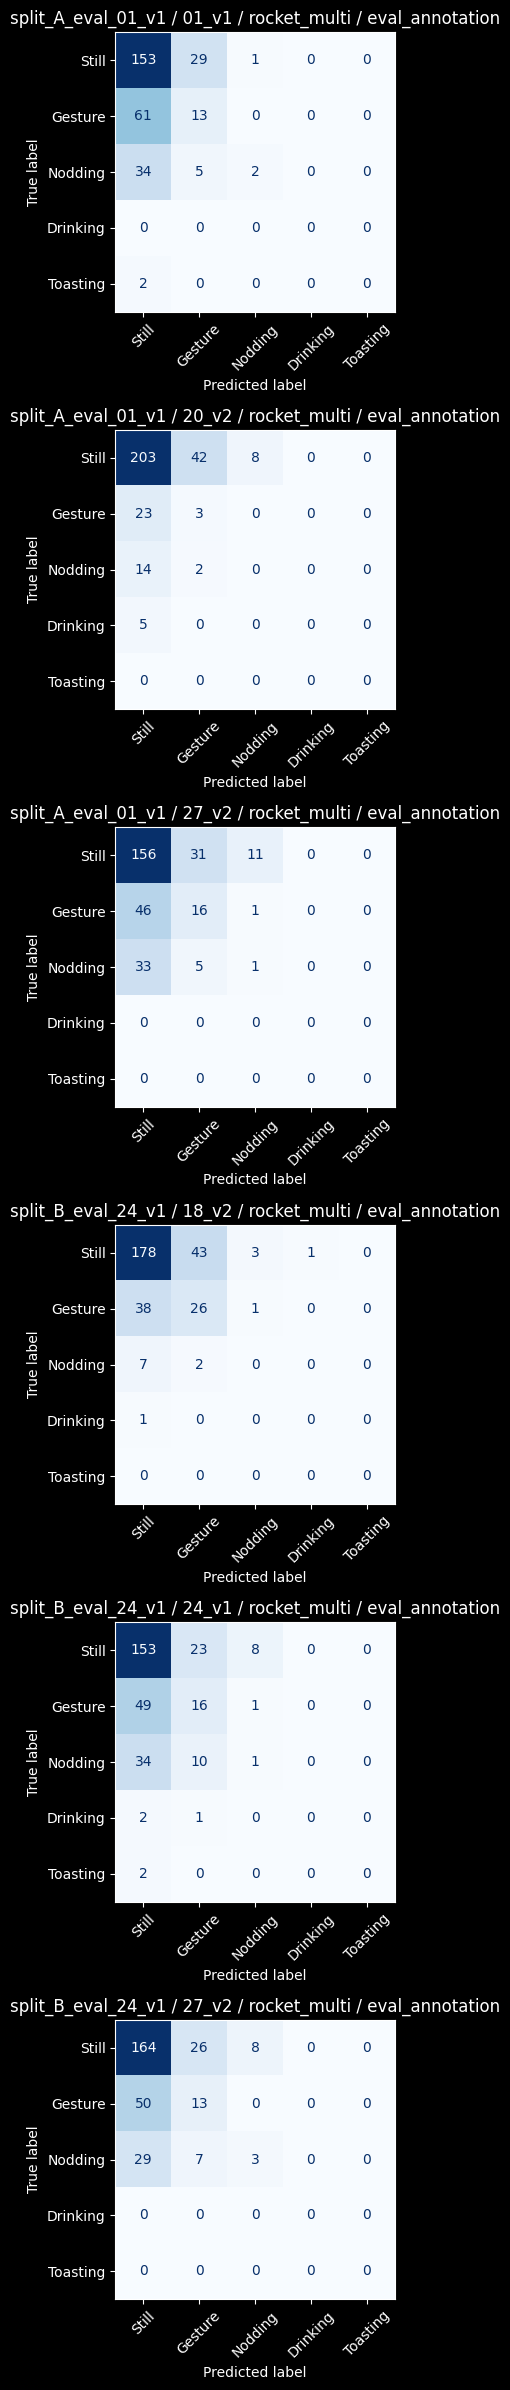

,split_config,annotation_id,model,split,accuracy,macro_precision,macro_recall,macro_f1,active_accuracy,active_macro_precision_no_still,active_macro_recall_no_still,active_macro_f1_no_still,n_samples,active_n_samples
7,split_B_eval_24_v1,27_v2,rocket_multi,eval_annotation,0.600000,0.410078,0.370518,0.367432,0.156863,0.825000,0.141636,0.228055,300,102
4,split_A_eval_01_v1,27_v2,rocket_multi,eval_annotation,0.576667,0.349482,0.355829,0.345759,0.166667,0.630952,0.139805,0.214866,300,102
5,split_B_eval_24_v1,18_v2,rocket_multi,eval_annotation,0.680000,0.290210,0.297778,0.293806,0.346667,0.309524,0.133333,0.186380,300,75
2,split_A_eval_01_v1,01_v1,rocket_multi,eval_annotation,0.560000,0.388816,0.265130,0.253121,0.128205,0.574074,0.074819,0.125211,300,117
6,split_B_eval_24_v1,24_v1,rocket_multi,eval_annotation,0.566667,0.211500,0.219234,0.206785,0.146552,0.273148,0.066162,0.096660,300,116
3,split_A_eval_01_v1,20_v2,rocket_multi,eval_annotation,0.686667,0.223100,0.229439,0.224363,0.063830,0.200000,0.038462,0.064516,300,47


,split_config,annotation_id,model,split,accuracy,macro_precision,macro_recall,macro_f1,active_accuracy,active_macro_precision_no_still,active_macro_recall_no_still,active_macro_f1_no_still,n_samples,active_n_samples
0,split_A_eval_01_v1,ALL_EVAL,rocket_multi,eval_split,0.607778,0.209110,0.207028,0.201571,0.131579,0.369318,0.056892,0.092295,900,266
1,split_B_eval_24_v1,ALL_EVAL,rocket_multi,eval_split,0.615556,0.237897,0.228400,0.225186,0.201365,0.350000,0.081629,0.122433,900,293


Quick performance read:
- split_B_eval_24_v1 / 27_v2: eval acc=0.600, active acc=0.157, active macro-F1(no Still)=0.228
- split_A_eval_01_v1 / 27_v2: eval acc=0.577, active acc=0.167, active macro-F1(no Still)=0.215
- split_B_eval_24_v1 / 18_v2: eval acc=0.680, active acc=0.347, active macro-F1(no Still)=0.186
- split_A_eval_01_v1 / 01_v1: eval acc=0.560, active acc=0.128, active macro-F1(no Still)=0.125
- split_B_eval_24_v1 / 24_v1: eval acc=0.567, active acc=0.147, active macro-F1(no Still)=0.097
- split_A_eval_01_v1 / 20_v2: eval acc=0.687, active acc=0.064, active macro-F1(no Still)=0.065


In [33]:
n_rows = len(splits) * 3
fig, axes = plt.subplots(n_rows, 1, figsize=(6, 4 * n_rows))
if n_rows == 1:
    axes = np.array([axes])
axes = np.asarray(axes).reshape(-1)

row_idx = 0
for split_name, split_data in splits.items():
    eval_pred = predictions[split_name]["eval"]
    for annotation_id in split_data["eval_meta"]["annotation_id"].drop_duplicates():
        annotation_mask = split_data["eval_meta"]["annotation_id"].eq(annotation_id).to_numpy()
        ConfusionMatrixDisplay.from_predictions(
            split_data["y_eval"][annotation_mask],
            eval_pred[annotation_mask],
            labels=label_order,
            display_labels=label_order,
            xticks_rotation=45,
            colorbar=False,
            cmap="Blues",
            ax=axes[row_idx],
        )
        axes[row_idx].set_title(f"{split_name} / {annotation_id} / rocket_multi / eval_annotation")
        row_idx += 1

fig.tight_layout()
plt.show()

eval_results = results_df[results_df["split"] == "eval_annotation"].sort_values("active_macro_f1_no_still", ascending=False)
display(eval_results)

display(eval_split_summary_df)

print("Quick performance read:")
for _, row in eval_results.iterrows():
    print(
        f"- {row['split_config']} / {row['annotation_id']}: eval acc={row['accuracy']:.3f}, "
        f"active acc={row['active_accuracy']:.3f}, active macro-F1(no Still)={row['active_macro_f1_no_still']:.3f}"
    )
